In [1]:
# Jupyter cell: make & save a vertical water-depth colorbar PNG
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display, Image as IPyImage


def save_water_depth_colorbar_png(
    out_path="water_depth_cbar_vertical.png",
    *,
    edges=(0.05, 0.10, 0.30, 0.50, 1.00, 1.50, 2.00, 2.50, 3.00, 3.50),
    colors=(
        "#f7fcf0",  # 0.05–0.10
        "#ccebc5",  # 0.10–0.30
        "#a8ddb5",  # 0.30–0.50
        "#7bccc4",  # 0.50–1.00
        "#4eb3d3",  # 1.00–1.50
        "#2b8cbe",  # 1.50–2.00
        "#08589e",  # 2.00–2.50
        "#08306b",  # 2.50–3.00
        "#54278f",  # 3.00–3.50
    ),
    overflow_color="#4d004b",   # ≥ 3.5 m
    label="Water depth (m)",
    fig_height=5.5,
    fig_width=1.6,
    dpi=400
):
    """
    Creates a vertical discrete colorbar matching the LISFLOOD
    water-depth plots (including violet overflow) and saves it as PNG.
    """
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)

    # --- build cmap & norm ---
    colors_ext = list(colors) + [overflow_color]
    cmap_disc = ListedColormap(colors_ext)
    cmap_disc.set_under((0, 0, 0, 0))  # transparent for < first edge
    norm = BoundaryNorm(edges, cmap_disc.N, extend="max")

    # --- figure ---
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    ax = fig.add_axes([0.35, 0.05, 0.25, 0.90])  # [left, bottom, width, height]

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
    sm.set_array([])

    cbar = plt.colorbar(
        sm,
        cax=ax,
        orientation="vertical",
        extend="max",
        ticks=list(edges),
    )

    cbar.set_label(label, rotation=90, labelpad=12, fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    # clean look
    for spine in ("top", "right", "left", "bottom"):
        cbar.ax.spines[spine].set_visible(False)

    fig.patch.set_alpha(0.0)
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=True)
    plt.close(fig)

    print(f"✅ Saved colorbar to: {out_path}")
    display(IPyImage(filename=out_path))


✅ Saved colorbar to: /storage/homefs/ge24z347/Liestal_event/water_depth_cbar_vertical.png


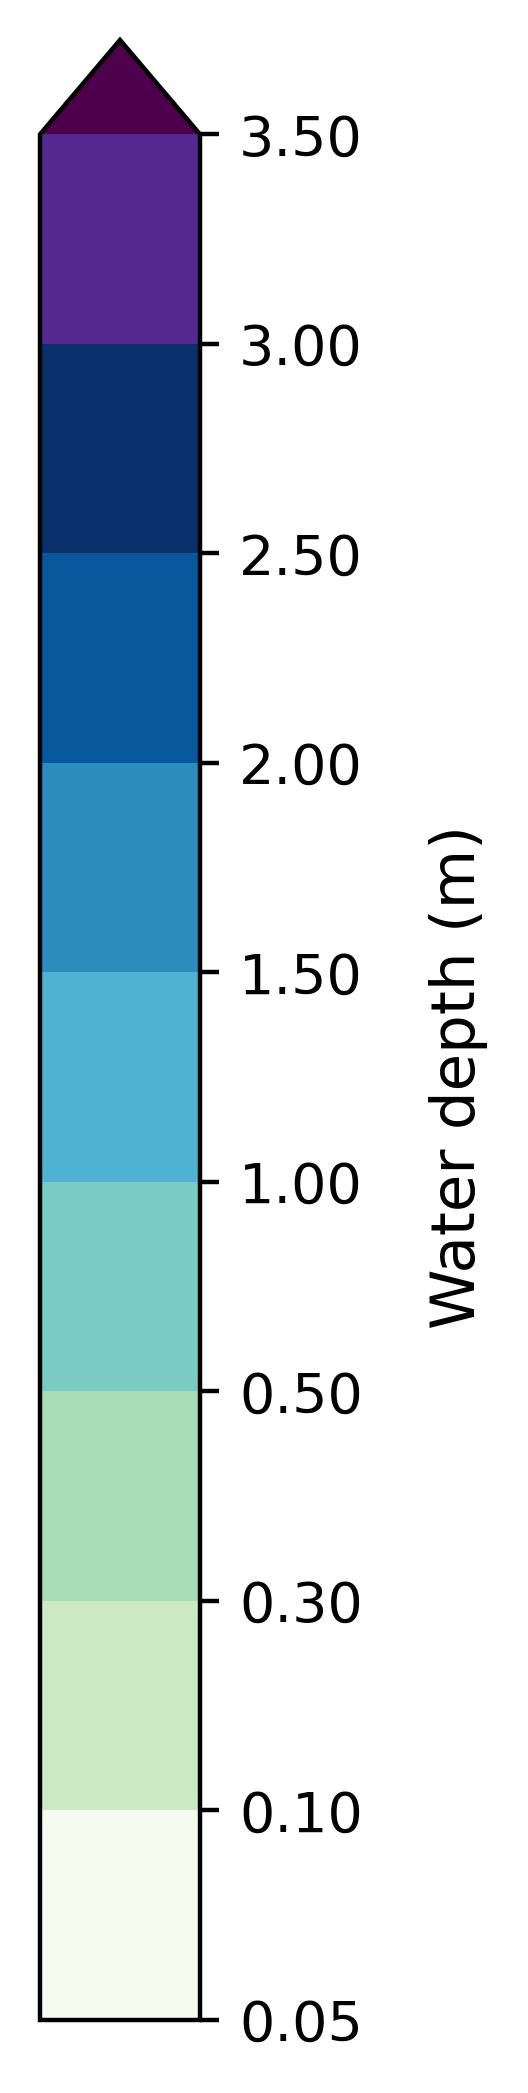

In [2]:
save_water_depth_colorbar_png(
    out_path="/storage/homefs/ge24z347/Liestal_event/water_depth_cbar_vertical.png",
    label="Water depth (m)"
)